<a href="https://colab.research.google.com/github/rakshitha01-a11y/house-price-prediction/blob/main/Paris_house_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. ESSENTIAL LIBRARIES IMPORT
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [2]:
# Ignore warnings for a clean output
warnings.filterwarnings('ignore')

In [11]:
# 2. DATA ACQUISITION
from google.colab import files
print("ParisHousing.csv)")
uploaded = files.upload()

ParisHousing.csv)


Saving ParisHousing.csv to ParisHousing (3).csv


In [12]:
# Load the dataset dynamically
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

In [13]:
# 3. INITIAL DATA EXPLORATION (EDA)
print("\n--- DATASET PREVIEW ---")
print(df.head())
print("\n--- DATASET INFO ---")
print(df.info())


--- DATASET PREVIEW ---
   squareMeters  numberOfRooms  hasYard  hasPool  floors  cityCode  \
0         75523              3        0        1      63      9373   
1         80771             39        1        1      98     39381   
2         55712             58        0        1      19     34457   
3         32316             47        0        0       6     27939   
4         70429             19        1        1      90     38045   

   cityPartRange  numPrevOwners  made  isNewBuilt  hasStormProtector  \
0              3              8  2005           0                  1   
1              8              6  2015           1                  0   
2              6              8  2021           0                  0   
3             10              4  2012           0                  1   
4              3              7  1990           1                  0   

   basement  attic  garage  hasStorageRoom  hasGuestRoom      price  
0      4313   9005     956               0         

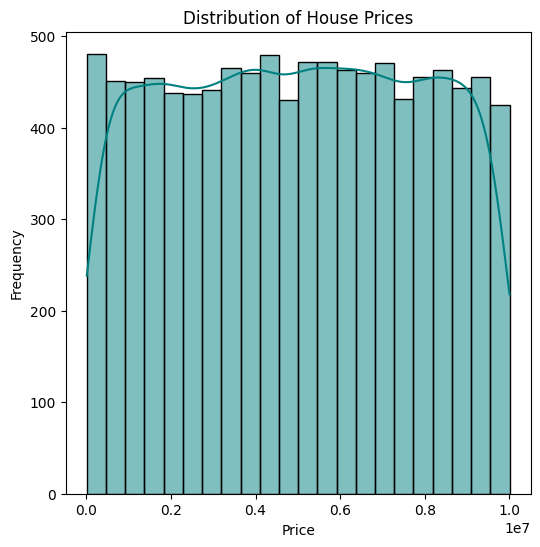

In [36]:
# Visualizing the Target Variable (Price)
plt.figure(figsize=(6, 6))
sns.histplot(df['price'], kde=True, color='teal')
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

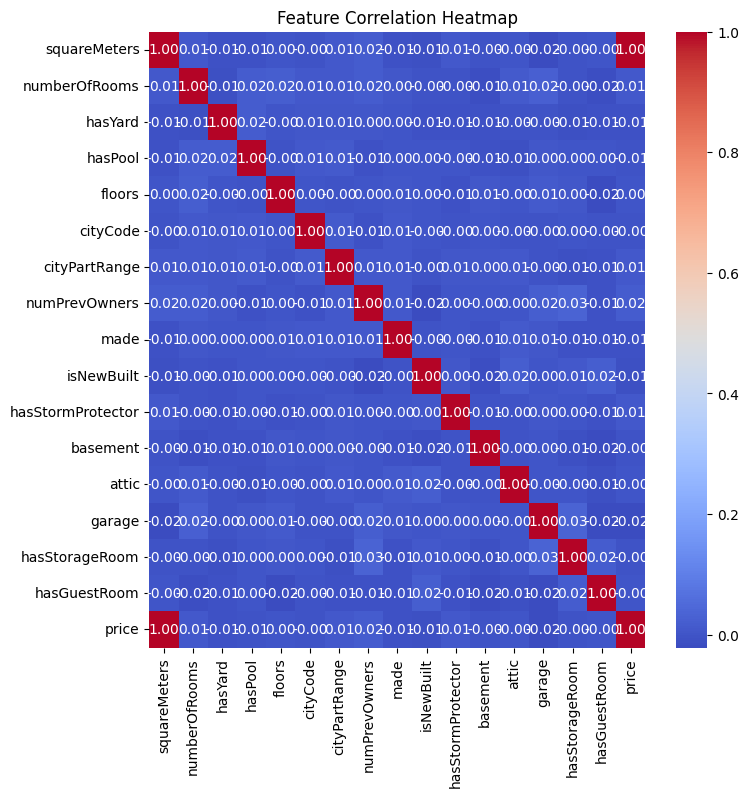

In [35]:
# 4. CORRELATION ANALYSIS
# Understanding which features affect the price most
plt.figure(figsize=(8, 8))
correlation_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

In [16]:
# 5. DATA PREPROCESSING PIPELINE
print("\nStep 2: Preparing Data for Machine Learning...")


Step 2: Preparing Data for Machine Learning...


In [18]:
# Separating Target (y) and Features (X)
X = df.drop('price', axis=1)
y = df['price']

In [19]:
# Identifying column types
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Creating Transformers
# Numeric: Fill missing values with median and Scale data
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [23]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Categorical: Fill missing values and Convert text to numbers
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [25]:
from sklearn.compose import ColumnTransformer

# Combine Preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [26]:
# 6. SPLITTING DATA
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
# 7. MODEL SELECTION AND TRAINING
print("\nStep 3: Training Multiple Models...")

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}


Step 3: Training Multiple Models...


In [31]:
# Iterate through models and store results
model_results = []

for name, model in models.items():
    # Create a pipeline that first preprocesses, then trains the model
    clf = Pipeline(steps=[('preprocessor', preprocessor),
                          ('regressor', model)])

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    # Calculate Metrics
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    model_results.append({"Model": name, "R2 Score": r2, "MAE": mae, "RMSE": rmse})
    print(f"{name} trained successfully.")

Linear Regression trained successfully.
Random Forest trained successfully.
Gradient Boosting trained successfully.


In [32]:
# 8. RESULTS COMPARISON
results_df = pd.DataFrame(model_results).sort_values(by='R2 Score', ascending=False)
print("\n--- MODEL PERFORMANCE COMPARISON ---")
print(results_df)


--- MODEL PERFORMANCE COMPARISON ---
               Model  R2 Score           MAE          RMSE
0  Linear Regression  1.000000   1510.034181   1922.422545
1      Random Forest  0.999998   3183.823977   4001.329902
2  Gradient Boosting  0.999954  15281.903572  20169.668273


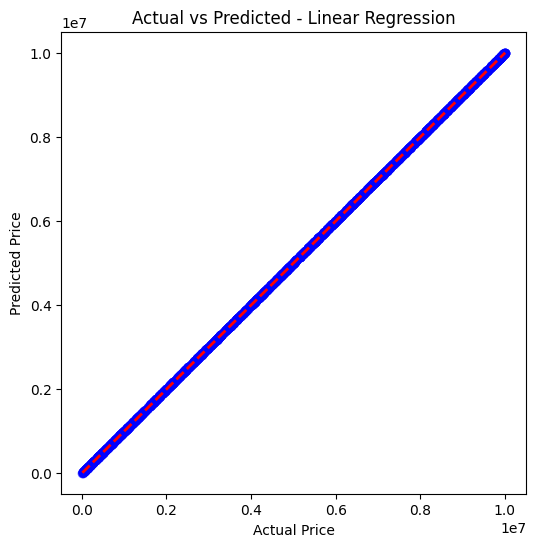

In [34]:
# 9. FINAL PREDICTION VISUALIZATION
# Using the top performing model for visualization
best_model_name = results_df.iloc[0]['Model']
best_model = Pipeline(steps=[('preprocessor', preprocessor),
                             ('regressor', models[best_model_name])])
best_model.fit(X_train, y_train)
final_predictions = best_model.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, final_predictions, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f'Actual vs Predicted - {best_model_name}')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.show()